#  Data Quality Report — Group 15

This notebook explores the quality of our dataset, focusing on balance, quirks, and potential issues before model training.

In [75]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df = pd.read_csv("/Users/apple/Desktop/group_15_url_combined_transcript.csv")

In [76]:
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3679 entries, 0 to 3678
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Start Time    3679 non-null   object
 1   End Time      3679 non-null   object
 2   Sentence      3679 non-null   object
 3   Translation   3674 non-null   object
 4   Emotion_fine  3674 non-null   object
 5   Emotion_core  3674 non-null   object
 6   Intensity     3674 non-null   object
dtypes: object(7)
memory usage: 201.3+ KB


In [77]:
print("Initial shape:", df.shape)

dup_count = df.duplicated().sum()
print("Duplicate rows found:", dup_count)

print("\nMissing values per column:\n", df.isna().sum())

df = df.drop_duplicates()
print("\nShape after removing duplicates:", df.shape)

critical_cols = ["Sentence", "Emotion_core"]  
df = df.dropna(subset=critical_cols)
print("Shape after dropping nulls in critical columns:", df.shape)


print("\nMissing values per column (after cleaning):\n", df.isna().sum())


Initial shape: (3679, 7)
Duplicate rows found: 20

Missing values per column:
 Start Time      0
End Time        0
Sentence        0
Translation     5
Emotion_fine    5
Emotion_core    5
Intensity       5
dtype: int64

Shape after removing duplicates: (3659, 7)
Shape after dropping nulls in critical columns: (3654, 7)

Missing values per column (after cleaning):
 Start Time      0
End Time        0
Sentence        0
Translation     0
Emotion_fine    0
Emotion_core    0
Intensity       0
dtype: int64


In [78]:
df.columns

Index(['Start Time', 'End Time', 'Sentence', 'Translation', 'Emotion_fine',
       'Emotion_core', 'Intensity'],
      dtype='object')

In [ ]:
df["sentence_length"] = df["Sentence"].astype(str).apply(lambda x: len(x.split()))
print("\nAverage sentence length:", df["sentence_length"].mean())


Average sentence length: 4.330870279146141


In [80]:
all_tokens = " ".join(df["Sentence"].astype(str)).split()
vocab_size = len(set(all_tokens))
print("Vocabulary size:", vocab_size)

Vocabulary size: 4362


### Sentence Length Distribution


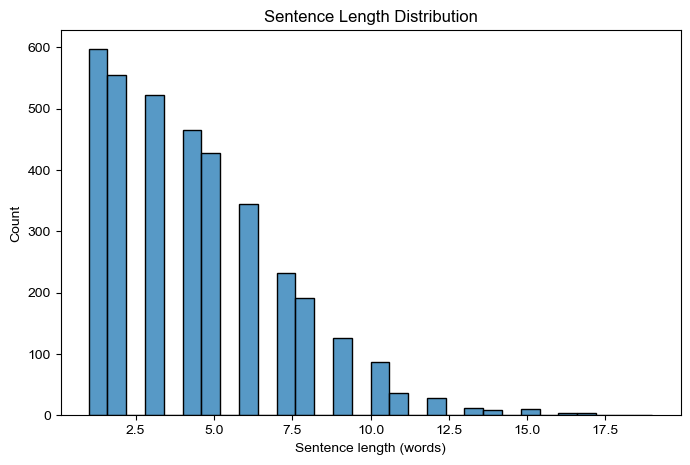

In [81]:
plt.figure(figsize=(8,5))
sns.histplot(df["sentence_length"], bins=30, kde=False)
plt.title("Sentence Length Distribution")
plt.xlabel("Sentence length (words)")
plt.ylabel("Count")
plt.show()

### Token Distribution

In [146]:
print(df.columns)
print(df["Sentence"].head())


Index(['Start Time', 'End Time', 'Sentence', 'Translation', 'Emotion_fine',
       'Emotion_core', 'Intensity', 'sentence_length', 'show_name',
       'Expected_core', 'Misspelled', 'NonAscii', 'NonPersian'],
      dtype='object')
0    PYM JBZ
1    PYM JBZ
2    PYM JBZ
3    PYM JBZ
4    PYM JBZ
Name: Sentence, dtype: object


### Token Distribution in Persian Sentences

In this section, we analyze the token distribution of the Persian sentences to better understand the spoken language characteristics.  
- First, all sentences are preprocessed by lowercasing and removing non-Persian characters.  
- Then, tokens (words) are extracted and their frequencies are counted.  
- The 20 most common tokens are displayed, which helps to identify frequent filler words and functional words (e.g., "که", "من", "تو").  
- Finally, a bar chart is plotted with reshaped and bidi-corrected Persian text to visualize the top tokens.  

This analysis shows which words dominate the spoken dataset, giving insights into the conversational style and presence of filler expressions.


Most common tokens: [('که', 370), ('من', 367), ('تو', 295), ('به', 293), ('این', 274), ('هم', 215), ('رو', 194), ('از', 190), ('و', 188), ('یه', 181), ('دیگه', 164), ('با', 147), ('خیلی', 133), ('اون', 108), ('ما', 94), ('نه', 91), ('باید', 90), ('بود', 85), ('چی', 84), ('در', 78)]


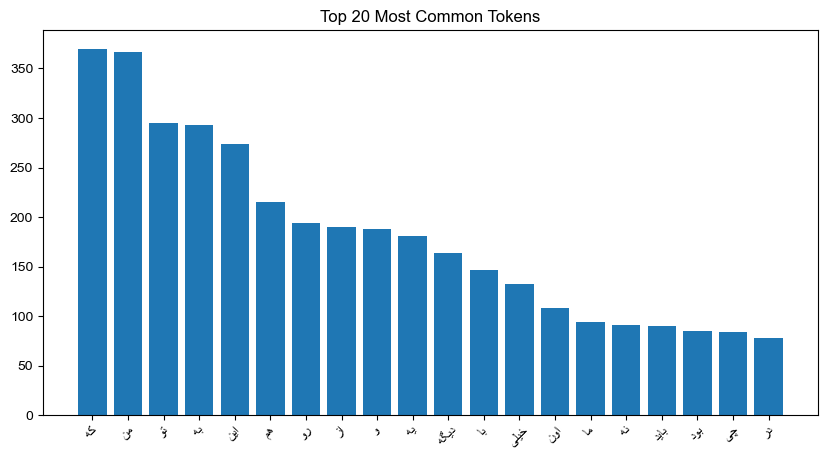

In [85]:
from collections import Counter
import arabic_reshaper
from bidi.algorithm import get_display
import matplotlib.pyplot as plt
import re

texts = df["Sentence"].dropna().astype(str)

def preprocess(text):
    text = text.lower()
    text = re.sub(r"[^\u0600-\u06FF\s]", "", text)
    return text

tokens = []
for sentence in texts:
    sentence = preprocess(sentence)
    tokens.extend(sentence.split())

token_counts = Counter(tokens)

common_tokens = token_counts.most_common(20)
print("Most common tokens:", common_tokens)

words, counts = zip(*common_tokens)

reshape_words = [arabic_reshaper.reshape(word) for word in words]
bidi_words = [get_display(word) for word in reshape_words]

plt.rcParams['font.family'] = 'Arial'
plt.figure(figsize=(10, 5))
plt.bar(bidi_words, counts)
plt.xticks(rotation=45)
plt.title("Top 20 Most Common Tokens")
plt.show()

### Show Distributions to Detect Dominance

In this step, we manually assign show labels to the dataset.  
  Rows 0–1695 are labeled as **Ham_refigh**.  
  Rows 1996–3680 are labeled as **Metri_6**.  
This allows us to later analyze the distribution of emotions across different shows.


In [94]:
import pandas as pd

df["show_name"] = ""

df.loc[0:1695, "show_name"] = "Ham_refigh"
df.loc[1996:3680, "show_name"] = "metri_6"

print(df[["Sentence", "show_name"]].head(20))   
print(df[["Sentence", "show_name"]].iloc[1690:1700])  
print(df[["Sentence", "show_name"]].iloc[1990:2000])  


   Sentence   show_name
0   PYM JBZ  Ham_refigh
1   PYM JBZ  Ham_refigh
2   PYM JBZ  Ham_refigh
3   PYM JBZ  Ham_refigh
4   PYM JBZ  Ham_refigh
5   PYM JBZ  Ham_refigh
6   PYM JBZ  Ham_refigh
7   PYM JBZ  Ham_refigh
8   PYM JBZ  Ham_refigh
9   PYM JBZ  Ham_refigh
10  PYM JBZ  Ham_refigh
11  PYM JBZ  Ham_refigh
12  PYM JBZ  Ham_refigh
13  PYM JBZ  Ham_refigh
14  PYM JBZ  Ham_refigh
15  PYM JBZ  Ham_refigh
16  PYM JBZ  Ham_refigh
17  PYM JBZ  Ham_refigh
18  PYM JBZ  Ham_refigh
19  PYM JBZ  Ham_refigh
              Sentence   show_name
1690      که باشی بابا  Ham_refigh
1691           آن دشمن  Ham_refigh
1692  بده دست تو به من  Ham_refigh
1693              دلتن  Ham_refigh
1694              کردم  Ham_refigh
1695           PYM JBZ  Ham_refigh
1703           PYM JBZ            
1704           PYM JBZ            
1705           PYM JBZ            
1706           PYM JBZ            
                                               Sentence show_name
2011                                         

In [ ]:
import matplotlib.pyplot as plt 

show_counts = df["show_name"].value_counts()

show_percent = df["show_name"].value_counts(normalize=True) * 100

print("Show distribution (counts):")
print(show_counts)

print("\nShow distribution (percentages):")
print(show_percent)


Show distribution (counts):
show_name
Ham_refigh    1696
metri_6       1679
               279
Name: count, dtype: int64

Show distribution (percentages):
show_name
Ham_refigh    46.414888
metri_6       45.949644
               7.635468
Name: proportion, dtype: float64


In [ ]:
Emotion_dist = df.groupby("show_name")["Emotion_core"].value_counts(normalize=True).unstack().fillna(0)
Emotion_dist_percent = df.groupby("show_name")["Emotion_core"].value_counts(normalize=True).unstack().fillna(0) * 100


print("\nEmotion distribution (percentages):")
print(Emotion_dist_percent)


Emotion distribution (percentages):
Emotion_core      anger   disgust      fear  happiness    neutral    sadness  \
show_name                                                                      
              10.394265  0.358423  4.659498   6.810036  70.250896   4.659498   
Ham_refigh     4.952830  0.707547  3.125000  24.056604  48.879717  15.448113   
metri_6       18.046456  2.561048  9.053008   7.206671  39.666468  15.842764   

Emotion_core  surprise  
show_name               
              2.867384  
Ham_refigh    2.830189  
metri_6       7.623585  


| show_name  | anger  | disgust | fear  | happiness | neutral | sadness | surprise |
|------------|--------|---------|-------|-----------|---------|---------|----------|
| Ham_refigh |  4.95% |   0.71% | 3.12% |   24.06%  |  48.88% |  15.45% |   2.83%  |
| metri_6    | 18.05% |   2.56% | 9.05% |    7.21%  |  39.67% |  15.84% |   7.62%  |


### whether important emotions are underrepresented

In [107]:
emotion_count = df["Emotion_core"].value_counts()
emotion_percents = df["Emotion_core"].value_counts(normalize=True) * 100

emotion_table = pd.DataFrame({
    "Count": emotion_count,
    "Percentage": emotion_percents.round(2)
})

print("Emotion dostribution:")
print(emotion_table)

threshold = 5
underrepresented = emotion_table[emotion_table["Percentage"] < threshold]

print("\nUnderrepresented emotions (<5% of data):")
print(underrepresented)

Emotion dostribution:
              Count  Percentage
Emotion_core                   
neutral        1691       46.28
happiness       548       15.00
sadness         541       14.81
anger           416       11.38
fear            218        5.97
surprise        184        5.04
disgust          56        1.53

Underrepresented emotions (<5% of data):
              Count  Percentage
Emotion_core                   
disgust          56        1.53


### linguistic patterns
Here we display a random sample of 20 sentences from the dataset.  
This helps to qualitatively inspect the data, check for natural spoken language features (e.g., short phrases, fillers), and identify possible transcription artifacts.

In [108]:
sample_sentences = df["Sentence"].dropna().sample(20, random_state=42)

print("Random sample of sentences:")
for i, sentence in enumerate(sample_sentences, 1):
    print(f"{i}. {sentence}")

Random sample of sentences:
1. دیگه موشه
2. میشه بردار
3. پارتنرت بهتر دیده بشه
4. تا خونه که دوش زندگی می کنن
5. اصلا معلوم نیست باشه
6. باشه یه ضرب از سر فیلم برداریم میام
7. خدا را شکرم
8. جاپونی و مشتری اون بودم بدونو که بفهمه سر خوردن سمت من
9. هم خیلی رفیقیم
10. تا منم بهت بگم تو میده کسی که
11. سرنگ
12. واسه برادرم کردم به خدا به خاطر بچه هاشون بوده
13. رزا
14. PYM JBZ
15. هر که دیدی بیاد ببین بگی من برگره پارکانو بریزم
16. به عنوان با یه همراه
17. ده کیلو غذا میکروی چهار شیش جا میشه؟
18. رزا
19. عشقانی
20. اسمو شما رو هم نداره


##### Artifact

In [111]:
artifact_mask = df["Sentence"].str.contains(r"[^آ-ی\s]", na=False)
artifacts_count = artifact_mask.sum()

artifact_percent = (artifacts_count / len(df)) * 100

print(f"Total artifacts: {artifacts_count}")
print(f"Percentage of artifacts in dataset: {artifact_percent:.2f}%")


Total artifacts: 784
Percentage of artifacts in dataset: 21.46%


#### hesitation



In [115]:
hesitation_words = ["ام", "اِمم", "اه", "آها", "خب", "یعنی"]

hesitations = df[df["Sentence"].str.contains("|".join(hesitation_words), na=False)]["Sentence"]

print(f"Total hesitations: {len(hesitations)}")


Total hesitations: 416


### Mislabeled emotions

In [133]:
core_groups = df.groupby('Emotion_core')['Emotion_fine'].unique()

for core, fines in core_groups.items():
    print(f"\nCore Emotion: {core}")
    print(f"Fine Emotions: {list(fines)[:20]} ...") 


Core Emotion: anger
Fine Emotions: ['frustration', 'defensiveness', 'resentment', 'annoyance', 'suspicion', 'hostility', 'aggression', 'conflict', 'impatience', 'confrontation', 'rejection', 'irritation', 'dominance', 'betrayal', 'injustice', 'command', 'refusal', 'defiance', 'dismissal', 'insistence'] ...

Core Emotion: disgust
Fine Emotions: ['annoyance', 'judgment', 'reluctance', 'sarcasm', 'contempt', 'distrust', 'dismissal', 'mockery', 'disapproval', 'disgust', 'dismissiveness', 'jealousy', 'skepticism', 'displeasure', 'rejection', 'discomfort', 'horror', 'weariness', 'envy', 'aversion'] ...

Core Emotion: fear
Fine Emotions: ['concern', 'uncertainty', 'warning', 'mystery', 'hesitation', 'insecurity', 'doubt', 'anxiety', 'dread', 'caution', 'panic', 'anticipation', 'pleading', 'apprehension', 'alarm', 'worry', 'reluctance', 'unease', 'self-consciousness', 'wariness'] ...

Core Emotion: happiness
Fine Emotions: ['fondness', 'affection', 'closeness', 'enjoyment', 'trust', 'longing'

Here we analyze the mapping between fine-grained emotions and core emotions.  
We group by `Emotion_fine` and `Emotion_core` to count occurrences.  
Then we identify fine emotions that appear under more than one core category.  

These cases are considered **suspicious** because they may indicate mislabeled or inconsistent annotations.  
For example, emotions like *anticipation* or *confusion* were found across multiple core categories, which can confuse the model during training.

In [134]:
fine_core_counts = df.groupby(['Emotion_fine','Emotion_core']).size().reset_index(name='count')
multi_core = fine_core_counts.groupby('Emotion_fine').size().reset_index(name='core_count')

suspicious_fines = multi_core[multi_core['core_count'] > 1]
print(suspicious_fines.head(20))


     Emotion_fine  core_count
1      acceptance           2
15      agreement           2
20      annoyance           2
21   anticipation           4
25   appreciation           2
29  assertiveness           2
30      assurance           2
37       betrayal           2
40       boasting           2
41        boredom           2
56        command           2
57  companionship           2
59     compassion           2
63        concern           4
67     confidence           2
71      confusion           5
72     connection           2
73  consideration           2
75       contempt           2
81    cooperation           2


### Misspellings

In [136]:
df['Sentence'].apply(lambda x: [c for c in str(x) if ord(c) > 2000 and ord(c) < 2300]).head()


0    []
1    []
2    []
3    []
4    []
Name: Sentence, dtype: object

In [139]:
from spellchecker import SpellChecker
import pandas as pd

spell = SpellChecker()

def find_misspelled(text):
    words = str(text).split()
    misspelled = spell.unknown(words)
    return list(misspelled)

df['Misspelled'] = df['Translation'].apply(find_misspelled)

misspellings_df = df[df['Misspelled'].str.len() > 0]
print(misspellings_df[['Translation','Misspelled']].head(10))


  Translation  Misspelled
0     PYM JBZ  [jbz, pym]
1     PYM JBZ  [jbz, pym]
2     PYM JBZ  [jbz, pym]
3     PYM JBZ  [jbz, pym]
4     PYM JBZ  [jbz, pym]
5     PYM JBZ  [jbz, pym]
6     PYM JBZ  [jbz, pym]
7     PYM JBZ  [jbz, pym]
8     PYM JBZ  [jbz, pym]
9     PYM JBZ  [jbz, pym]


### Encoding Errors

In [140]:
def has_non_ascii(text):
    return any(ord(c) > 127 for c in str(text))

df['NonAscii'] = df['Translation'].apply(has_non_ascii)
encoding_issues = df[df['NonAscii'] == True]

print(encoding_issues[['Translation']].head(20))


                                            Translation
413      The best compliment I give is also very cliché
539              Let's tell Afshé not to smoke anymore.
811                                    He said 'شبکاره'
1744                                                🐶🐶🐶
1745                                                🐶🐶🐶
1746                                                🐶🐶🐶
1747                                                🐶🐶🐶
1776                                     Go away, Göden
1791                                    This is slip он
2027                                            قارندhn
2119                  He/she has been Naser's fiancé(e)
2120            Where do you know Naser's fiancée from?
2766  I’ll call for them to bring a pizza and its si...
3271                                           بplement


In [141]:
import re

def has_non_persian(text):
    return any(not re.match(r'[\u0600-\u06FF\s،؛؟]', c) for c in str(text))

df['NonPersian'] = df['Sentence'].apply(has_non_persian)
encoding_issues_fa = df[df['NonPersian'] == True]

print(encoding_issues_fa[['Sentence']].head(20))


   Sentence
0   PYM JBZ
1   PYM JBZ
2   PYM JBZ
3   PYM JBZ
4   PYM JBZ
5   PYM JBZ
6   PYM JBZ
7   PYM JBZ
8   PYM JBZ
9   PYM JBZ
10  PYM JBZ
11  PYM JBZ
12  PYM JBZ
13  PYM JBZ
14  PYM JBZ
15  PYM JBZ
16  PYM JBZ
17  PYM JBZ
18  PYM JBZ
19  PYM JBZ


### imbalance or systematic gaps

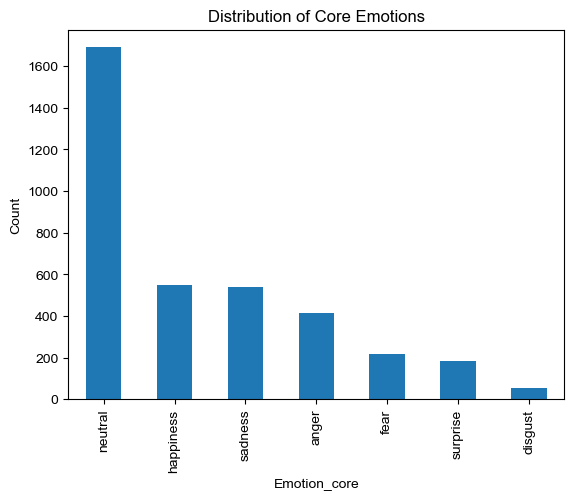

Emotion_core
neutral      1691
happiness     548
sadness       541
anger         416
fear          218
surprise      184
disgust        56
Name: count, dtype: int64


In [142]:
import matplotlib.pyplot as plt

core_counts = df['Emotion_core'].value_counts()
core_counts.plot(kind='bar')
plt.title("Distribution of Core Emotions")
plt.ylabel("Count")
plt.show()

print(core_counts)


In [143]:
fine_counts = df['Emotion_fine'].value_counts()
print("Top 10 most frequent fine emotions:\n", fine_counts.head(10))
print("\nBottom 10 least frequent fine emotions:\n", fine_counts.tail(10))


Top 10 most frequent fine emotions:
 Emotion_fine
neutrality      405
curiosity       320
confusion       195
resignation     186
expectation     108
uncertainty      95
resentment       87
anticipation     76
frustration      74
acceptance       68
Name: count, dtype: int64

Bottom 10 least frequent fine emotions:
 Emotion_fine
awe                1
industriousness    1
love               1
description        1
defeat             1
clarification      1
critique           1
hospitality        1
drowsiness         1
exclamation        1
Name: count, dtype: int64


Intensity
mild            1603
neutral         1240
moderate         717
intense           93
overwhelming       1
Name: count, dtype: int64


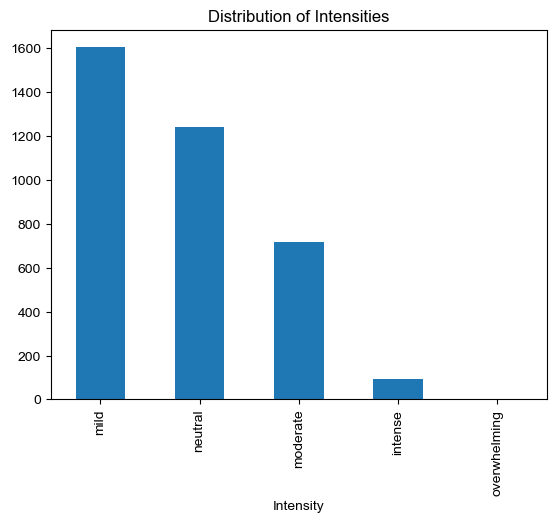

In [144]:
intensity_counts = df['Intensity'].value_counts()
print(intensity_counts)
intensity_counts.plot(kind='bar', title="Distribution of Intensities")
plt.show()


In [145]:
cross_tab = pd.crosstab(df['Emotion_core'], df['Intensity'])
print(cross_tab)


Intensity     intense  mild  moderate  neutral  overwhelming
Emotion_core                                                
anger              27   134       255        0             0
disgust             8    13        34        0             1
fear               19   117        82        0             0
happiness          10   478        60        0             0
neutral             0   439        12     1240             0
sadness            27   292       222        0             0
surprise            2   130        52        0             0


# Reflective Analysis

1. Dataset Profile and Domain Characteristics
The dataset, after cleaning, consists of 3,654 rows with an average sentence length of about 4.3 words. This short length reflects conversational speech but also limits how much emotional content can be expressed in each line. The vocabulary size is 4,362 tokens, with the most common tokens being filler or functional words such as “که,” “من,” and “تو.” However, around 21.5% of the data contains artifacts such as non-Persian characters, corrupted tokens, or placeholders like “PYM JBZ”. These artifacts reduce the reliability of the dataset and could distort the model’s learning process if not removed or replaced with meaningful text. This indicates a need for cleaner transcripts and possibly re-checking transcription pipelines.

2. Emotion Distribution and Coverage
There is a clear imbalance in the distribution of core emotions. Neutral dominates the dataset with 46% of all samples (1,691 sentences), while emotions such as disgust are severely underrepresented with only 56 cases (1.5%). Surprise (5%) and fear (6%) are also relatively rare. In contrast, happiness (15%) and sadness (15%) are better represented. At the fine level, the imbalance is even clearer: neutrality and curiosity occur over 300 times, while emotions like awe, love, and hospitality occur only once. This imbalance means the model will likely overfit to neutral or mild emotional states and fail to recognize rare but important emotions. For example, if disgust is almost absent, the model may misclassify disgust expressions as anger or sadness.

3. Data Quality Issues (Mislabeled, Misspellings, Encoding Errors)
Inconsistencies were found in the mapping of fine to core emotions. For example, anticipation appears under four different core emotions (fear, happiness, neutral, surprise) and confusion under five different cores. This lack of consistency makes it difficult for the model to learn clear distinctions. Additionally, some translations are corrupted, such as “قارندhn” or “slip он”, and non-words like “PYM JBZ” appear frequently. These highlight systematic errors in transcription or translation. Spellchecking flagged these as misspellings, confirming their invalidity. Such noise must be either cleaned or removed, as it introduces errors that the model could mistakenly learn.

4. Intensity Distribution
The dataset shows a strong imbalance in intensity labels. Most data is labeled as mild (1,603 cases) or neutral (1,240), while intense emotions occur only 93 times and overwhelming just once. For example, anger has 134 mild and 255 moderate samples but only 27 intense ones. This systematic gap means the dataset does not capture the full range of emotional intensity. As a result, the model will likely perform poorly when faced with strong emotional expressions in real TV data. More training examples of strong and overwhelming emotions are needed to balance this.

5. Show and Speaker Distribution
The dataset is intentionally split between two movies, Ham_refigh (46%) and Metri_6 (46%), which gives us a balanced distribution between the two sources. This setup ensures that neither show completely dominates the dataset. However, around 7% of the data does not belong to either category and has no clear show label. This portion is problematic because we cannot confirm its source, and it may either introduce noise or represent useful diversity that is currently unaccounted for. Going forward, we need to carefully inspect this 7% to decide whether it should be assigned to one of the two shows, categorized separately, or excluded from training to avoid inconsistencies.

6. Implications for Training Data
Overall, the dataset provides a valuable foundation but requires supplementation. Several improvements are necessary to make the training data more reliable and representative. First, corrupted rows such as those labeled with meaningless placeholders like “PYM JBZ” should be removed, as they add noise and do not contribute to meaningful learning. Second, the ~7% of data that does not belong to either of the two shows must be addressed: it should be reviewed and either reassigned to the correct show, placed in a separate category, or excluded if its source cannot be verified. Finally, to reduce imbalance, additional data should be collected for underrepresented emotions such as disgust, fear, and surprise, particularly in their stronger intensity levels. Ideally, such data augmentation should be performed on a regular basis (e.g., annually) to ensure that the dataset evolves to cover the full emotional spectrum of spoken television dialogue. By addressing these issues, the training data will more accurately reflect the diversity of spoken TV language and emotional expression, and the resulting models will be more robust and fair across all emotion categories.